1️⃣ Introduction

KNN is a supervised machine learning algorithm used for classification and regression.

👉 It works on a simple idea:

A data point is classified based on the majority class of its nearest neighbors.

Example:
If most of the nearest points are Red, the new point becomes Red.

2️⃣ How KNN Works

Choose number of neighbors → K

Calculate distance between test point & all training points

Select nearest K point
Majority vote → Final class

Common distance:

Euclidean distance (most popular)

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

In [2]:
data = {
    "hours": [1,2,3,4,5,6,7,8,2,3,6,7,8,9,4,5,1,9,10,6],
    "attendance": [50,55,60,65,70,75,80,85,40,60,70,90,95,88,72,68,45,92,98,78],
    "result": [0,0,0,0,1,1,1,1,0,0,1,1,1,1,1,0,0,1,1,1]
}

df = pd.DataFrame(data)
df.head()


,hours,attendance,result
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,0
4,5,70,1


👉 0 = Fail
👉 1 = Pass

4️⃣ Visualize Students

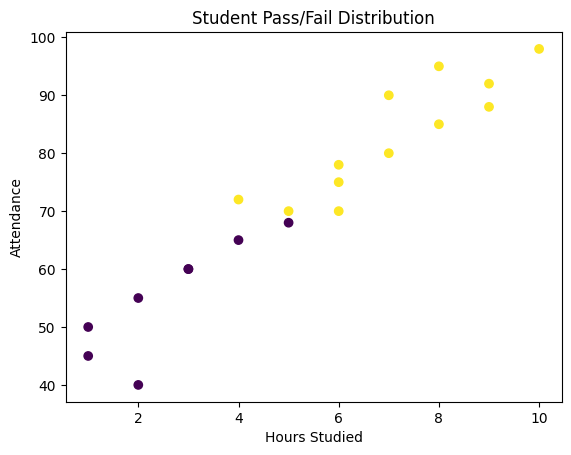

In [3]:
plt.scatter(df["hours"], df["attendance"], c=df["result"])
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student Pass/Fail Distribution")
plt.show()


Prepare Data

In [4]:
X = df[["hours", "attendance"]]
y = df["result"]


Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


7️⃣ Create KNN Model

In [6]:
k = 3
model = KNeighborsClassifier(n_neighbors=k)


Train Model

In [7]:
model.fit(X_train, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
# save
joblib.dump(model, "knn_student_model.pkl")

['knn_student_model.pkl']

Prediction

In [9]:
X_test

,hours,attendance
0,1,50
17,9,92
15,5,68
1,2,55


In [10]:
y_pred = model.predict(X_test)
print(y_pred)


[0 1 1 0]


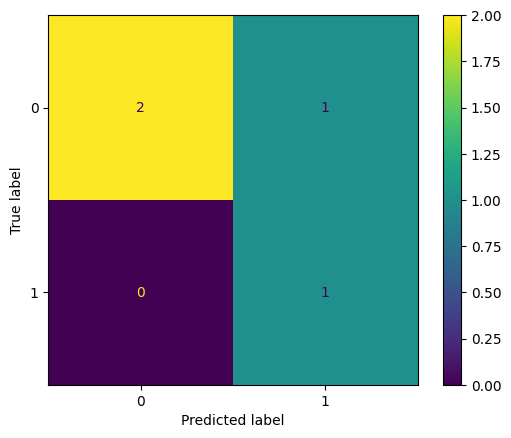

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


Confusion Matrix

c:\Users\anand\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


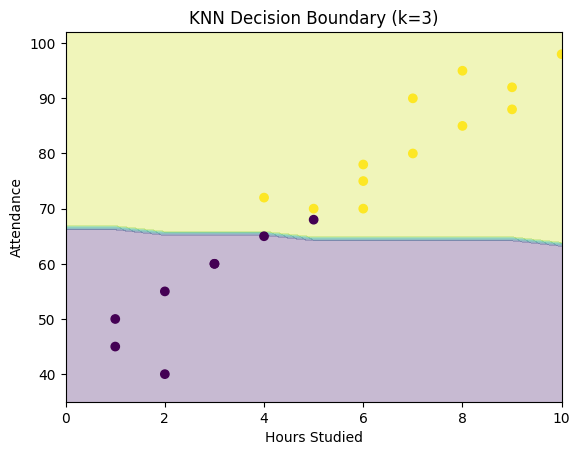

In [12]:
h = 1

x_min, x_max = X["hours"].min() - 1, X["hours"].max() + 1
y_min, y_max = X["attendance"].min() - 5, X["attendance"].max() + 5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X["hours"], X["attendance"], c=y)
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title(f"KNN Decision Boundary (k={k})")
plt.show()
